# Visual Inspection: PlanetScope Download Pipeline

This notebook tests each function in `download_planetscope.py` step by step to confirm the pipeline works correctly.

**Functions tested:**
1. `initialize_planet()` - API authentication
2. `point_to_aoi()` - Create bounding box geometry
3. `search_scenes()` - Find available imagery
4. `order_and_download_batch()` - Submit order and download
5. `apply_udm2_mask()` - Cloud masking
6. `retrieve_time_series_stack()` - Full single-site pipeline

## Setup

In [ ]:
import sys
import os
from datetime import datetime

# Add project root to path
sys.path.insert(0, os.path.abspath('../../../../'))

# Import functions to test
from src.features.download_planetscope import (
    initialize_planet,
    point_to_aoi,
    search_scenes,           # async - use with await
    order_and_download_batch, # async - use with await  
    apply_udm2_mask,
    retrieve_time_series_stack,  # async - use with await
    search_best_scenes_for_windows,
    PS_BANDS,
)

print("Imports successful!")
print(f"PlanetScope bands: {PS_BANDS}")
print("\nIn notebooks, use 'await' with async functions")

## 1. Test Authentication

Reads API key from `secrets/planet-api-key.txt`

In [2]:
api_key = initialize_planet()
print(f"API key loaded: {api_key[:8]}...{api_key[-4:]}")

2026-01-26 10:45:49,913 - INFO - Planet API initialized.


API key loaded: PLAKe71c...ba00


## 2. Test Bounding Box Creation

Uses geodesic calculations via `geopy` for accuracy.

In [3]:
# Test location in Zambia (from your study area)
test_lat = -15.5
test_lon = 28.3

aoi = point_to_aoi(test_lon, test_lat)

print("AOI GeoJSON:")
print(f"  Type: {aoi['type']}")
print(f"  Coordinates: {aoi['coordinates']}")

# Visualize the bounding box
coords = aoi['coordinates'][0]
lons = [c[0] for c in coords]
lats = [c[1] for c in coords]

print(f"\nBounding box:")
print(f"  Lon range: {min(lons):.6f} to {max(lons):.6f}")
print(f"  Lat range: {min(lats):.6f} to {max(lats):.6f}")

# Calculate approximate size
from geopy.distance import distance
width_km = distance((min(lats), min(lons)), (min(lats), max(lons))).km
height_km = distance((min(lats), min(lons)), (max(lats), min(lons))).km
print(f"  Size: {width_km:.3f} km x {height_km:.3f} km")

AOI GeoJSON:
  Type: Polygon
  Coordinates: (((28.304659984117123, -15.504518604088144), (28.304659984117123, -15.495481394067967), (28.29534001588288, -15.495481394067967), (28.29534001588288, -15.504518604088144), (28.304659984117123, -15.504518604088144)),)

Bounding box:
  Lon range: 28.295340 to 28.304660
  Lat range: -15.504519 to -15.495481
  Size: 1.000 km x 1.000 km


## 3. Test Scene Search

Search for PlanetScope imagery in a time window.

In [6]:
# Search for scenes in a 10-day window
# Using await because we're in a Jupyter notebook (which has an event loop)

results = await search_scenes(
    lat=test_lat,
    lon=test_lon,
    start_date='2023-06-01',
    end_date='2023-06-10',
    max_cloud_cover=0.5
)

print(f"Found {len(results)} scenes\n")

if results:
    print("Top 5 scenes (sorted by cloud cover):")
    print("-" * 60)
    for i, scene in enumerate(results[:5]):
        props = scene['properties']
        print(f"{i+1}. {scene['id']}")
        print(f"   Acquired: {props.get('acquired', 'N/A')}")
        print(f"   Cloud cover: {props.get('cloud_cover', 'N/A'):.1%}")
        print(f"   Effective coverage: {scene.get('effective_coverage', 'N/A')}")
        print()

2026-01-26 10:48:09,666 - INFO - Session read timeout set to 125.0 seconds.
2026-01-26 10:48:09,710 - INFO - POST https://api.planet.com/data/v1/quick-search - Sent
2026-01-26 10:48:09,917 - INFO - HTTP Request: POST https://api.planet.com/data/v1/quick-search "HTTP/1.1 200 OK"
2026-01-26 10:48:09,918 - INFO - POST https://api.planet.com/data/v1/quick-search - Status 200
2026-01-26 10:48:09,923 - INFO - POST https://api.planet.com/data/v1/item-types/PSScene/items/20230607_072632_25_2439/coverage?mode=estimate - Sent


Footprint coverage for item 20230607_072632_25_2439 : 32.530075332369336


2026-01-26 10:48:10,331 - INFO - HTTP Request: POST https://api.planet.com/data/v1/item-types/PSScene/items/20230607_072632_25_2439/coverage?mode=estimate "HTTP/1.1 200 OK"
2026-01-26 10:48:10,332 - INFO - POST https://api.planet.com/data/v1/item-types/PSScene/items/20230607_072632_25_2439/coverage?mode=estimate - Status 200
2026-01-26 10:48:10,336 - INFO - POST https://api.planet.com/data/v1/item-types/PSScene/items/20230607_072630_16_2439/coverage?mode=estimate - Sent


Footprint coverage for item 20230607_072630_16_2439 : 99.96632337652791


2026-01-26 10:48:10,868 - INFO - HTTP Request: POST https://api.planet.com/data/v1/item-types/PSScene/items/20230607_072630_16_2439/coverage?mode=estimate "HTTP/1.1 200 OK"
2026-01-26 10:48:10,869 - INFO - POST https://api.planet.com/data/v1/item-types/PSScene/items/20230607_072630_16_2439/coverage?mode=estimate - Status 200
2026-01-26 10:48:10,872 - INFO - POST https://api.planet.com/data/v1/item-types/PSScene/items/20230606_072444_37_2430/coverage?mode=estimate - Sent


...

Footprint coverage for item 20230602_075033_40_2262 : 99.12643387977488


2026-01-26 10:48:12,805 - INFO - HTTP Request: POST https://api.planet.com/data/v1/item-types/PSScene/items/20230602_075033_40_2262/coverage?mode=estimate "HTTP/1.1 200 OK"
2026-01-26 10:48:12,806 - INFO - POST https://api.planet.com/data/v1/item-types/PSScene/items/20230602_075033_40_2262/coverage?mode=estimate - Status 200
2026-01-26 10:48:12,811 - INFO - POST https://api.planet.com/data/v1/item-types/PSScene/items/20230601_080530_98_2438/coverage?mode=estimate - Sent


Footprint coverage for item 20230601_080530_98_2438 : 100.0


2026-01-26 10:48:13,261 - INFO - HTTP Request: POST https://api.planet.com/data/v1/item-types/PSScene/items/20230601_080530_98_2438/coverage?mode=estimate "HTTP/1.1 200 OK"
2026-01-26 10:48:13,261 - INFO - POST https://api.planet.com/data/v1/item-types/PSScene/items/20230601_080530_98_2438/coverage?mode=estimate - Status 200


Found 8 scenes

Top 5 scenes (sorted by cloud cover):
------------------------------------------------------------
1. 20230606_072444_37_2430
   Acquired: 2023-06-06T07:24:44.377905Z
   Cloud cover: 0.0%
   Effective coverage: 100.0

2. 20230604_073009_79_24b5
   Acquired: 2023-06-04T07:30:09.798182Z
   Cloud cover: 0.0%
   Effective coverage: 100.0

3. 20230603_073055_49_24b4
   Acquired: 2023-06-03T07:30:55.499556Z
   Cloud cover: 0.0%
   Effective coverage: 100.0

4. 20230601_080530_98_2438
   Acquired: 2023-06-01T08:05:30.98525Z
   Cloud cover: 0.0%
   Effective coverage: 100.0

5. 20230607_072630_16_2439
   Acquired: 2023-06-07T07:26:30.163147Z
   Cloud cover: 0.0%
   Effective coverage: 99.96632337652791



In [5]:
# Test with a very restrictive cloud cover to see "no results" handling
results_strict = await search_scenes(
    lat=test_lat,
    lon=test_lon,
    start_date='2023-06-01',
    end_date='2023-06-01',  # Very short window
    max_cloud_cover=0.01    # Very strict
)

print(f"Strict search found {len(results_strict)} scenes")
print("(This tests handling of windows with no available imagery)")

2026-01-26 10:28:35,418 - INFO - Session read timeout set to 125.0 seconds.
2026-01-26 10:28:35,455 - INFO - POST https://api.planet.com/data/v1/quick-search - Sent
2026-01-26 10:28:35,686 - INFO - HTTP Request: POST https://api.planet.com/data/v1/quick-search "HTTP/1.1 200 OK"
2026-01-26 10:28:35,686 - INFO - POST https://api.planet.com/data/v1/quick-search - Status 200


Strict search found 0 scenes
(This tests handling of windows with no available imagery)


### 3b. Test AOI-Specific Coverage Checking

The scene-level `clear_percent` tells us how much of the entire ~25km PlanetScope scene is clear. But our AOI is only 1km x 1km. We need to know:

1. **Footprint coverage**: Does the scene geometry fully cover our AOI? (edge clipping)
2. **Clear coverage**: Is our AOI cloud-free? (via Planet's `get_item_coverage` API)

We combine these into **effective coverage** = footprint × clear, then sort by this score. No hard thresholds - we always pick the best available scene for each time window.

In [6]:
# Test AOI-specific coverage checking
# This calculates:
# 1. Footprint coverage: what % of our 1km AOI is covered by the scene geometry
# 2. Clear coverage: what % of the AOI is cloud-free (via Planet's get_item_coverage API)
# 3. Effective coverage: footprint * clear (combined usable area)

print("Testing AOI-specific coverage checking...")
print("=" * 60)

# Search with AOI coverage checking enabled (default)
results_with_aoi_check = await search_scenes(
    lat=test_lat,
    lon=test_lon,
    start_date='2023-06-01',
    end_date='2023-06-10',
    max_cloud_cover=0.5,
    check_aoi_coverage=True
)

print(f"Found {len(results_with_aoi_check)} scenes (sorted by effective coverage)\n")

if results_with_aoi_check:
    print("Top 5 scenes:")
    print(f"{'Rank':<5} {'Scene ID':<32} {'Footprint':<12} {'AOI Clear':<12} {'Effective':<10}")
    print("-" * 75)
    for i, scene in enumerate(results_with_aoi_check[:5]):
        footprint = scene.get('footprint_coverage', 0)
        aoi_clear = scene.get('aoi_clear_percent', 0)
        effective = scene.get('effective_coverage', 0)
        print(f"{i+1:<5} {scene['id'][:30]:<32} {footprint:>8.1f}%    {aoi_clear:>8.1f}%    {effective:>6.1f}%")

print("\n'Effective coverage' = footprint × clear fraction")
print("This is what we sort by - best available scene is always picked.")

2026-01-26 10:28:35,702 - INFO - Session read timeout set to 125.0 seconds.
2026-01-26 10:28:35,746 - INFO - POST https://api.planet.com/data/v1/quick-search - Sent


Testing AOI-specific coverage checking...


2026-01-26 10:28:35,970 - INFO - HTTP Request: POST https://api.planet.com/data/v1/quick-search "HTTP/1.1 200 OK"
2026-01-26 10:28:35,971 - INFO - POST https://api.planet.com/data/v1/quick-search - Status 200
2026-01-26 10:28:35,975 - INFO - POST https://api.planet.com/data/v1/item-types/PSScene/items/20230607_072632_25_2439/coverage?mode=estimate - Sent
2026-01-26 10:28:36,429 - INFO - HTTP Request: POST https://api.planet.com/data/v1/item-types/PSScene/items/20230607_072632_25_2439/coverage?mode=estimate "HTTP/1.1 200 OK"
2026-01-26 10:28:36,430 - INFO - POST https://api.planet.com/data/v1/item-types/PSScene/items/20230607_072632_25_2439/coverage?mode=estimate - Status 200
2026-01-26 10:28:36,435 - INFO - POST https://api.planet.com/data/v1/item-types/PSScene/items/20230607_072630_16_2439/coverage?mode=estimate - Sent
2026-01-26 10:28:36,904 - INFO - HTTP Request: POST https://api.planet.com/data/v1/item-types/PSScene/items/20230607_072630_16_2439/coverage?mode=estimate "HTTP/1.1 200

Found 8 scenes (sorted by effective coverage)

Top 5 scenes:
Rank  Scene ID                         Footprint    AOI Clear    Effective 
---------------------------------------------------------------------------
1     20230606_072444_37_2430             100.0%       100.0%     100.0%
2     20230604_073009_79_24b5             100.0%       100.0%     100.0%
3     20230603_073055_49_24b4             100.0%       100.0%     100.0%
4     20230601_080530_98_2438             100.0%       100.0%     100.0%
5     20230607_072630_16_2439             100.0%       100.0%     100.0%

'Effective coverage' = footprint × clear fraction
This is what we sort by - best available scene is always picked.


## 4. Inspect Scene Metadata

Look at what information is available for each scene.

In [7]:
if results:
    best_scene = results[0]
    
    print("Best scene structure:")
    print(f"  ID: {best_scene['id']}")
    print(f"  Type: {best_scene.get('type', 'N/A')}")
    print(f"\nProperties:")
    for key, value in best_scene.get('properties', {}).items():
        print(f"  {key}: {value}")
    
    print(f"\nAssets available: {list(best_scene.get('assets', [])) if 'assets' in best_scene else 'Not in search results'}")
    
    # Check if geometry is available (for footprint coverage check)
    if 'geometry' in best_scene:
        print(f"\nScene geometry type: {best_scene['geometry'].get('type', 'N/A')}")
        print("(Scene footprint is available for AOI intersection check)")

Best scene structure:
  ID: 20230606_072444_37_2430
  Type: Feature

Properties:
  acquired: 2023-06-06T07:24:44.377905Z
  anomalous_pixels: 0
  clear_confidence_percent: 97
  clear_percent: 100
  cloud_cover: 0
  cloud_percent: 0
  ground_control: True
  gsd: 3.7
  heavy_haze_percent: 0
  instrument: PSB.SD
  item_type: PSScene
  light_haze_percent: 0
  pixel_resolution: 3
  provider: planetscope
  published: 2023-06-06T14:56:43Z
  publishing_stage: finalized
  quality_category: standard
  satellite_azimuth: 96.8
  satellite_id: 2430
  shadow_percent: 0
  snow_ice_percent: 0
  strip_id: 6559806
  sun_azimuth: 46.5
  sun_elevation: 35.5
  updated: 2023-06-07T04:15:34Z
  view_angle: 4.3
  visible_confidence_percent: 78
  visible_percent: 100

Assets available: ['basic_analytic_4b', 'basic_analytic_4b_rpc', 'basic_analytic_4b_xml', 'basic_analytic_8b', 'basic_analytic_8b_xml', 'basic_udm2', 'ortho_analytic_4b', 'ortho_analytic_4b_sr', 'ortho_analytic_4b_xml', 'ortho_analytic_8b', 'ortho_

## 5. Test Multi-Window Search

Search for best scene across multiple time windows (like we do for a full stack).

In [8]:
from datetime import timedelta

# Create 5 test windows (instead of 42, for quick testing)
start = datetime(2023, 6, 1)
test_windows = [
    (start + timedelta(days=i*10), start + timedelta(days=(i+1)*10))
    for i in range(5)
]

print("Test windows:")
for i, (s, e) in enumerate(test_windows):
    print(f"  {i}: {s.strftime('%Y-%m-%d')} to {e.strftime('%Y-%m-%d')}")

print("\nSearching for best scene in each window...")
window_results = await search_best_scenes_for_windows(
    lat=test_lat,
    lon=test_lon,
    time_windows=test_windows,
    max_cloud_cover=0.5
)

print("\nResults:")
for i, info in window_results.items():
    if info['item_id']:
        print(f"  Window {i}: {info['item_id'][:20]}... (cloud: {info['cloud_cover']:.1%})")
    else:
        print(f"  Window {i}: NO SCENE FOUND")

2026-01-26 10:28:39,228 - INFO - Session read timeout set to 125.0 seconds.
2026-01-26 10:28:39,270 - INFO - POST https://api.planet.com/data/v1/quick-search - Sent


Test windows:
  0: 2023-06-01 to 2023-06-11
  1: 2023-06-11 to 2023-06-21
  2: 2023-06-21 to 2023-07-01
  3: 2023-07-01 to 2023-07-11
  4: 2023-07-11 to 2023-07-21

Searching for best scene in each window...


2026-01-26 10:28:39,484 - INFO - HTTP Request: POST https://api.planet.com/data/v1/quick-search "HTTP/1.1 200 OK"
2026-01-26 10:28:39,485 - INFO - POST https://api.planet.com/data/v1/quick-search - Status 200
2026-01-26 10:28:39,488 - INFO - POST https://api.planet.com/data/v1/item-types/PSScene/items/20230607_072632_25_2439/coverage?mode=estimate - Sent
2026-01-26 10:28:39,814 - INFO - HTTP Request: POST https://api.planet.com/data/v1/item-types/PSScene/items/20230607_072632_25_2439/coverage?mode=estimate "HTTP/1.1 200 OK"
2026-01-26 10:28:39,815 - INFO - POST https://api.planet.com/data/v1/item-types/PSScene/items/20230607_072632_25_2439/coverage?mode=estimate - Status 200
2026-01-26 10:28:39,818 - INFO - POST https://api.planet.com/data/v1/item-types/PSScene/items/20230607_072630_16_2439/coverage?mode=estimate - Sent
2026-01-26 10:28:40,163 - INFO - HTTP Request: POST https://api.planet.com/data/v1/item-types/PSScene/items/20230607_072630_16_2439/coverage?mode=estimate "HTTP/1.1 200


Results:
  Window 0: 20230606_072444_37_2... (cloud: 0.0%)
  Window 1: 20230620_080308_20_2... (cloud: 0.0%)
  Window 2: 20230628_072912_22_2... (cloud: 0.0%)
  Window 3: 20230710_080450_20_2... (cloud: 0.0%)
  Window 4: 20230717_073029_13_2... (cloud: 0.0%)


## 6. Test Ordering and Downloading (SLOW - submits real order)

**Warning:** This submits a real order to Planet and may take 5-30 minutes to complete.

The order applies three processing tools (in this order):
1. **Reproject** - Puts all images on same north-aligned UTM grid at exactly 3m resolution (uses "near" kernel to minimize blurring)
2. **Coregister** - Fine sub-pixel alignment to anchor scene (works better after reproject since images are already on same grid)
3. **Clip** - Clips to our 1km × 1km AOI

At 3m resolution, our 1km AOI = 333 pixels × 333 pixels.

In [ ]:
# Set to True to run the actual order test
RUN_ORDER_TEST = True

if RUN_ORDER_TEST and results:
    # Use a local folder you can inspect (not tempfile)
    test_output_dir = './test_planet_downloads'
    os.makedirs(test_output_dir, exist_ok=True)
    
    # Use just 2 scenes for testing - first one is anchor (best effective_coverage)
    test_item_ids = [results[0]['id'], results[1]['id']] if len(results) > 1 else [results[0]['id']]
    anchor_id = results[0]['id']  # Best scene as anchor
    
    print(f"Submitting order for {len(test_item_ids)} scenes...")
    print(f"Scene IDs: {test_item_ids}")
    print(f"Anchor for coregistration: {anchor_id}")
    print(f"Output directory: {os.path.abspath(test_output_dir)}")
    
    # Submit order with clip, reproject, and coregister
    downloaded = await order_and_download_batch(
        item_ids=test_item_ids,
        lat=test_lat,
        lon=test_lon,
        output_dir=test_output_dir,
        order_name='test_order',
        anchor_id=anchor_id
    )
    
    print(f"\nDownloaded {len(downloaded)} scenes")
    for scene_id, (sr_path, masked_path) in downloaded.items():
        print(f"  {scene_id}:")
        print(f"    SR: {sr_path}")
        print(f"    Masked: {masked_path}")
else:
    print("Order test skipped. Set RUN_ORDER_TEST = True to run.")

## 7. Inspect Downloaded Data (if order test was run)

2026-01-26 10:42:21,402 - WARNING - CPLE_AppDefined in PROJ: internal_proj_create_from_database: Cannot find proj.db
2026-01-26 10:42:21,403 - WARNING - CPLE_AppDefined in The definition of projected CRS EPSG:32735 got from GeoTIFF keys is not the same as the one from the EPSG registry, which may cause issues during reprojection operations. Set GTIFF_SRS_SOURCE configuration option to EPSG to use official parameters (overriding the ones from GeoTIFF keys), or to GEOKEYS to use custom values from GeoTIFF keys and drop the EPSG code.
2026-01-26 10:42:21,403 - WARNING - CPLE_AppDefined in PROJ: internal_proj_create_from_name: Cannot find proj.db
2026-01-26 10:42:21,404 - INFO - GDAL signalled an error: err_no=1, msg='PROJ: internal_proj_identify: Cannot find proj.db'


Inspecting: ./test_planet_downloads/20230606_072444_37_2430_3B_AnalyticMS_SR_clip.tif

Raster info:
  Shape: (337, 336)
  Bands: 4
  CRS: PROJCS["WGS 84 / UTM zone 35S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",27],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
  Bounds: BoundingBox(left=638937.0, bottom=8285442.0, right=639945.0, top=8286453.0)
  Resolution: (3.0, 3.0)
  Dtype: uint16

Data shape: (4, 337, 336)
Data range: 0 to 4108


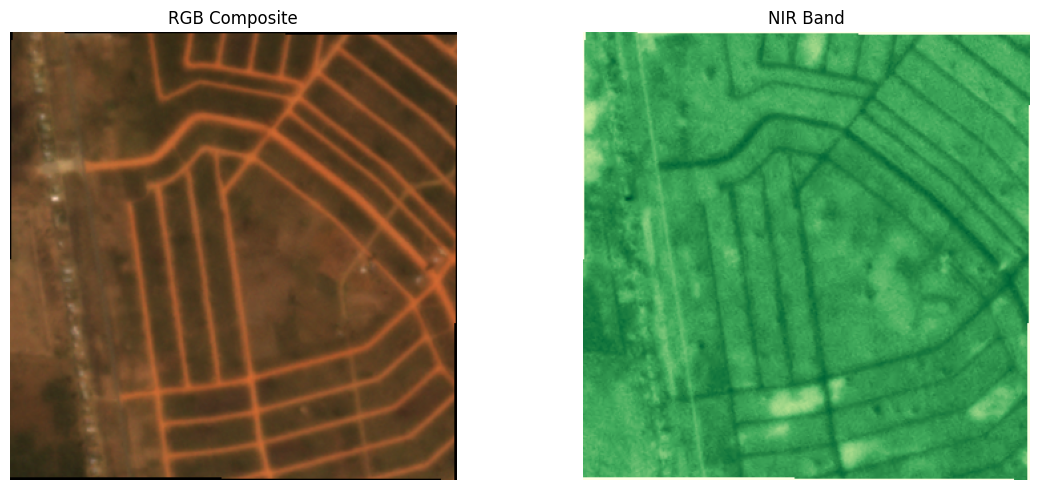

In [10]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

if RUN_ORDER_TEST and downloaded:
    # Get first downloaded scene
    scene_id, (sr_path, masked_path) = list(downloaded.items())[0]
    
    print(f"Inspecting: {sr_path}")
    
    with rasterio.open(sr_path) as src:
        print(f"\nRaster info:")
        print(f"  Shape: {src.shape}")
        print(f"  Bands: {src.count}")
        print(f"  CRS: {src.crs}")
        print(f"  Bounds: {src.bounds}")
        print(f"  Resolution: {src.res}")
        print(f"  Dtype: {src.dtypes[0]}")
        
        # Read data
        data = src.read()
        print(f"\nData shape: {data.shape}")
        print(f"Data range: {data.min()} to {data.max()}")
        
        # Plot RGB
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # RGB composite (bands: blue=0, green=1, red=2, nir=3)
        rgb = np.stack([data[2], data[1], data[0]], axis=0)  # R, G, B
        rgb = np.transpose(rgb, (1, 2, 0))
        rgb = np.clip(rgb / 3000, 0, 1)  # Scale for display
        
        axes[0].imshow(rgb)
        axes[0].set_title('RGB Composite')
        axes[0].axis('off')
        
        # NIR for vegetation
        axes[1].imshow(data[3], cmap='YlGn')
        axes[1].set_title('NIR Band')
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
else:
    print("No downloaded data to inspect. Run the order test first.")

## 8. Compare Unmasked vs Masked (if order test was run)

2026-01-26 10:43:06,854 - WARNING - CPLE_AppDefined in PROJ: internal_proj_create_from_database: Cannot find proj.db
2026-01-26 10:43:06,855 - WARNING - CPLE_AppDefined in The definition of projected CRS EPSG:32735 got from GeoTIFF keys is not the same as the one from the EPSG registry, which may cause issues during reprojection operations. Set GTIFF_SRS_SOURCE configuration option to EPSG to use official parameters (overriding the ones from GeoTIFF keys), or to GEOKEYS to use custom values from GeoTIFF keys and drop the EPSG code.
2026-01-26 10:43:06,855 - WARNING - CPLE_AppDefined in PROJ: internal_proj_create_from_name: Cannot find proj.db
2026-01-26 10:43:06,869 - WARNING - CPLE_AppDefined in PROJ: internal_proj_create_from_name: Cannot find proj.db


Masked pixels: 1.3%


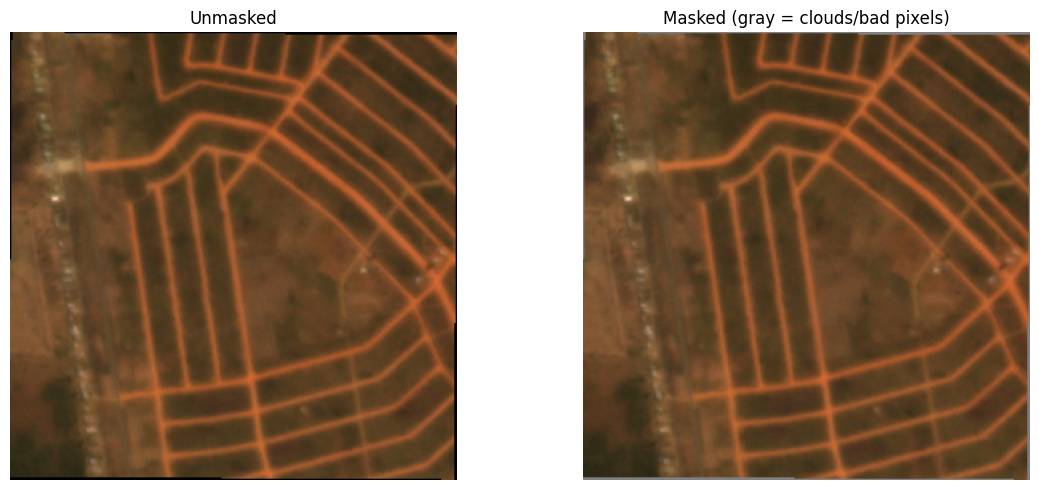

In [11]:
if RUN_ORDER_TEST and downloaded:
    scene_id, (sr_path, masked_path) = list(downloaded.items())[0]
    
    if masked_path and os.path.exists(masked_path):
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # Unmasked
        with rasterio.open(sr_path) as src:
            data_unmasked = src.read()
            rgb_unmasked = np.stack([data_unmasked[2], data_unmasked[1], data_unmasked[0]], axis=0)
            rgb_unmasked = np.transpose(rgb_unmasked, (1, 2, 0))
            rgb_unmasked = np.clip(rgb_unmasked / 3000, 0, 1)
        
        # Masked
        with rasterio.open(masked_path) as src:
            data_masked = src.read()
            rgb_masked = np.stack([data_masked[2], data_masked[1], data_masked[0]], axis=0)
            rgb_masked = np.transpose(rgb_masked, (1, 2, 0))
            rgb_masked = np.clip(rgb_masked / 3000, 0, 1)
            # Make masked pixels (0) transparent/gray
            mask = (data_masked == 0).all(axis=0)
            rgb_masked[mask] = [0.5, 0.5, 0.5]  # Gray for masked
        
        axes[0].imshow(rgb_unmasked)
        axes[0].set_title('Unmasked')
        axes[0].axis('off')
        
        axes[1].imshow(rgb_masked)
        axes[1].set_title('Masked (gray = clouds/bad pixels)')
        axes[1].axis('off')
        
        # Calculate masked percentage
        masked_pct = mask.sum() / mask.size * 100
        print(f"Masked pixels: {masked_pct:.1f}%")
        
        plt.tight_layout()
        plt.show()
    else:
        print("No masked file available")
else:
    print("No downloaded data to compare. Run the order test first.")

## 9. Test Full Stack Retrieval (SLOW)

This tests `retrieve_time_series_stack()` which:
1. Searches for best scene in each of 42 windows
2. Submits one batch order
3. Downloads and stacks all results

**Warning:** This will take 30+ minutes and download ~42 scenes.

In [ ]:
RUN_FULL_STACK_TEST = False

if RUN_FULL_STACK_TEST:
    # Use a local folder you can inspect
    test_output_dir = './test_planet_stack'
    os.makedirs(test_output_dir, exist_ok=True)
    print(f"Output directory: {os.path.abspath(test_output_dir)}")
    
    # Use await since retrieve_time_series_stack is async
    await retrieve_time_series_stack(
        file_id='test_site',
        lat=test_lat,
        lon=test_lon,
        date=datetime(2023, 1, 1),
        out_dir=test_output_dir,
        start_month=1,
        num_windows=36,
        timestep=10,
        window_buffer=3,
        target_size=333,
        max_cloud_cover=0.5
    )
    
    print(f"\nFiles created:")
    for f in os.listdir(test_output_dir):
        if not f.startswith('_'):
            path = os.path.join(test_output_dir, f)
            size_mb = os.path.getsize(path) / 1024 / 1024
            print(f"  {f}: {size_mb:.1f} MB")
else:
    print("Full stack test skipped. Set RUN_FULL_STACK_TEST = True to run.")

## Summary

| Function | Status | Notes |
|----------|--------|-------|
| `initialize_planet()` | | API key loaded? |
| `point_to_aoi()` | | ~1km x 1km box? |
| `search_scenes()` | | Found scenes? |
| `search_best_scenes_for_windows()` | | Found scene per window? |
| `order_and_download_batch()` | | Downloaded successfully? |
| `apply_udm2_mask()` | | Clouds masked? |
| `retrieve_time_series_stack()` | | Stack created? |